In [11]:
%load_ext autoreload
%autoreload 2

import json
from transformers import AutoProcessor
import sys 
import os 
# current_file_path = os.path.dirname(os.path.abspath(__file__))
# module_path = os.path.join(current_file_path, "../")
# sys.path.append(module_path)
# from models.qwen2_5_vl import Qwen2VLRetForConditionalGeneration
import torch 
import argparse
from dataset.datasets_mbeir import QueryDataset, CandidateDataset
from collators.mbeir_eval import MbeirQueryDataCollator, MbeirCandidateDataCollator
from torch.utils.data import DataLoader 
import torch.nn.functional as F 
import numpy as np
DATASET_QUERY_NUM_UPPER_BOUND = 500000
DATASET_CAN_NUM_UPPER_BOUND = 10000000

NUM_QUERIES = 30
NUM_CANDIDATES_FOR_POOL = 300 # Number of candidates to use in the evaluation pool for simulated retrieval
MAX_RETRIEVED_PER_QUERY = 50 # For simulated retrieval and recall calculation up to K=50


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:

def unhash_qid(hashed_qid):
    dataset_id = hashed_qid // DATASET_QUERY_NUM_UPPER_BOUND
    data_within_id = hashed_qid % DATASET_QUERY_NUM_UPPER_BOUND
    return f"{dataset_id}:{data_within_id}"

def unhash_did(hashed_did):
    dataset_id = hashed_did // DATASET_CAN_NUM_UPPER_BOUND
    data_within_id = hashed_did % DATASET_CAN_NUM_UPPER_BOUND
    return f"{dataset_id}:{data_within_id}"

def load_qrel(filename):
    qrel = {}
    qid_to_taskid = {}
    with open(filename, "r") as f:
        for line in f:
            query_id, _, doc_id, relevance_score, task_id = line.strip().split()
            if int(relevance_score) > 0:  # Assuming only positive relevance scores indicate relevant documents
                if query_id not in qrel:
                    qrel[query_id] = []
                qrel[query_id].append(doc_id)
                if query_id not in qid_to_taskid:
                    qid_to_taskid[query_id] = task_id
    print(f"Retriever: Loaded {len(qrel)} queries from {filename}")
    print(
        f"Retriever: Average number of relevant documents per query: {sum(len(v) for v in qrel.values()) / len(qrel):.2f}"
    )
    return qrel, qid_to_taskid

def compute_recall_at_k(relevant_docs, retrieved_indices, k):
    if not relevant_docs:
        return 0.0 # Return 0 if there are no relevant documents

    # Get the set of indices for the top k retrieved documents
    top_k_retrieved_indices_set = set(retrieved_indices[:k])

    # Convert the relevant documents to a set
    relevant_docs_set = set(relevant_docs)

    # Check if there is an intersection between relevant docs and top k retrieved docs
    # If there is, we return 1, indicating successful retrieval; otherwise, we return 0
    if relevant_docs_set.intersection(top_k_retrieved_indices_set):
        return 1.0
    else:
        return 0.0



In [60]:
DS_ID = 12
TASKID = "vismin_task6"
IMG_PATH = "/mbeir_images/vismin_images"

DS_ID = 13
TASKID = "dam_task0"
IMG_PATH = "/mbeir_images/dam_images"

DS_ID = 14
TASKID = "fgclip_task3"
IMG_PATH = "/mbeir_images/fgclip_images"

class Args:
    def __init__(self):
        # Define the environment variables from the command
        _MODEL_ID = "./checkpoints/LamRA-Ret"
        _ORIGINAL_MODEL_ID = "Qwen/Qwen2-VL-7B-Instruct"
        _IMAGE_PATH_PREFIX = "/mnt/tidal-alsh01/dataset/mmeb/M-BEIR"

        # Arguments passed in the command line
        self.query_data_path: str = f"{_IMAGE_PATH_PREFIX}/query/test/mbeir_{TASKID}_test.jsonl"
        self.query_cand_pool_path: str = f"{_IMAGE_PATH_PREFIX}/cand_pool/test/mbeir_{TASKID}_cand_pool.jsonl"
        self.cand_pool_path: str = f"{_IMAGE_PATH_PREFIX}/cand_pool/test/mbeir_{TASKID}_cand_pool.jsonl"
        self.instructions_path: str = f"{_IMAGE_PATH_PREFIX}/instructions/query_instructions.tsv"
        self.qrels_path: str = f"{_IMAGE_PATH_PREFIX}/qrels/test/mbeir_{TASKID}_test_qrels.txt"
        self.original_model_id: str = _ORIGINAL_MODEL_ID
        self.image_path_prefix: str = _IMAGE_PATH_PREFIX + IMG_PATH
        self.model_id: str = _MODEL_ID

        # Argument with a default value from the argparse definition (not overridden in the command)
        self.model_max_length: int = 1024

# xhs 评估指标验证

In [61]:
args = Args()
from dataset.datasets_mbeir import QueryDataset, CandidateDataset
from PIL import Image
cand_dataset = CandidateDataset(
    query_data_path=args.query_data_path, 
    cand_pool_path=args.cand_pool_path,
    instructions_path=args.instructions_path,
    image_path_prefix=args.image_path_prefix
)
query_dataset = QueryDataset(
    query_data_path=args.query_data_path, 
    cand_pool_path=args.query_cand_pool_path,
    instructions_path=args.instructions_path,
    image_path_prefix=args.image_path_prefix
)


In [62]:
qrel, _ = load_qrel(args.qrels_path)
cand_pool = {d['did']:d for d in cand_dataset.cand_pool}

Retriever: Loaded 1500 queries from /mnt/tidal-alsh01/dataset/mmeb/M-BEIR/qrels/test/mbeir_fgclip_task3_test_qrels.txt
Retriever: Average number of relevant documents per query: 1.00


In [90]:
def get_image_info(item_data, image_path_prefix=""):
    """
    统一获取图片信息的函数
    Args:
        item_data: 可以是query数据或candidate数据
        image_path_prefix: 图片路径前缀
    Returns:
        tuple: (image_path, box) 如果没有图片则返回 (None, None)
    """
    if isinstance(item_data, dict):
        # 处理candidate数据格式
        if 'img_path' in item_data:
            img_path = os.path.join(image_path_prefix, item_data['img_path'])
            box = item_data.get('box', None)
            return img_path, box
        return None, None
    elif isinstance(item_data, list):
        # 处理query数据格式
        try:
            if len(item_data) > 0 and 'content' in item_data[0]:
                content = item_data[0]['content']
                # 查找图片内容
                for item in content:
                    if 'image' in item:
                        return item['image'], item.get('box', None)
            return None, None
        except (KeyError, IndexError, TypeError):
            return None, None
    else:
        return None, None

def get_text_info(query_data):
    """
    统一获取文本信息的函数
    Args:
        query_data: query数据
    Returns:
        str: 文本内容，如果没有则返回空字符串
    """
    try:
        if isinstance(query_data, list) and len(query_data) > 0:
            content = query_data[0].get('content', [])
            for item in content:
                if 'text' in item:
                    return item['text']
        return ""
    except (KeyError, IndexError, TypeError):
        return ""

def show_items_with_images(items, image_path_prefix="", title_prefix="", max_items=10):
    """
    统一显示带图片的items（可以是query或candidates）
    Args:
        items: 要显示的items列表
        image_path_prefix: 图片路径前缀
        title_prefix: 标题前缀
        max_items: 最大显示数量
    """
    if not items:
        print(f"{title_prefix}No items to show")
        return
    
    image_paths = []
    box_list = []
    txt_list = []
    
    display_items = items[:max_items] if len(items) > max_items else items
    
    for item in display_items:
        try:
            img_path, box = get_image_info(item, image_path_prefix)
            if img_path:
                image_paths.append(img_path)
                box_list.append(box)
            else:
                print(f"{title_prefix}Warning: No image found for item")
        except:
            txt_list.append(item['txt'])

    if image_paths:
        print(f"{title_prefix}Showing {len(image_paths)} images")
        show_group_imgs(image_paths, box_list)
    if txt_list:
        print(txt_list)

def show_some_query_info(query_idx):
    """
    显示query信息的统一函数
    """
    query, _ = query_dataset[query_idx]
    
    # 获取并显示文本信息
    text_content = get_text_info(query)
    if text_content:
        print(f"Query text: {text_content}")
    
    # 获取query图片信息
    query_img_path, query_box = get_image_info(query)
    
    # 获取positive candidates
    poscand_did_list = qrel[f'{DS_ID}:{query_idx+1}']
    
    # 准备显示的图片列表
    all_items = []
    
    # 添加query（如果有图片）
    if query_img_path:
        print(f"Query box: {query_box}")
        # 创建一个类似candidate格式的字典来复用get_image_info
        query_item = {'img_path': query_img_path.replace(args.image_path_prefix + '/', ''), 'box': query_box}
        all_items.append(query_item)
    
    # 添加positive candidates
    for did in poscand_did_list:
        if did in cand_pool:
            all_items.append(cand_pool[did])
    
    # 显示所有图片
    if all_items:
        show_items_with_images(all_items, args.image_path_prefix, "Query and positive candidates: ")
    else:
        print("No images to display for this query")
    
    return query, poscand_did_list

def show_candidates_results(cand_names, query_idx, title="Results", max_display=10):
    """
    统一显示候选结果的函数
    Args:
        cand_names: 候选者did列表
        query_idx: query索引
        title: 显示标题
        max_display: 最大显示数量
    """
    print(f"\n{title}")
    
    if not cand_names:
        print("No candidates to show")
        return
    
    # 获取候选者数据
    candidates = []
    for i, did in enumerate(cand_names[:max_display]):
        if did in cand_pool:
            candidates.append(cand_pool[did])
        else:
            print(f"Warning: Candidate {did} not found in pool")
    
    # 显示候选者图片
    show_items_with_images(candidates, args.image_path_prefix, f"{title}: ", max_display)

def show_some_cand(did):
    """
    显示单个候选者
    """
    if did not in cand_pool:
        print(f"Candidate {did} not found")
        return None
    
    img_path, box = get_image_info(cand_pool[did], args.image_path_prefix)
    if img_path:
        return Image.open(img_path)
    else:
        print(f"No image for candidate {did}")
        return None

def show_group_imgs(image_paths, box_list=None, output_path=None):
    """
    显示图片组的函数，增加了错误处理
    """
    def draw(image_path, box):
        from PIL import Image, ImageDraw
        
        try:
            image = Image.open(image_path)
        except Exception as e:
            print(f"Error opening image {image_path}: {e}")
            return None
            
        if box is None: 
            return image
            
        width, height = image.size
        x0 = width * box[0]
        y0 = height * box[1]
        x1 = width * box[2]
        y1 = height * box[3]


        draw = ImageDraw.Draw(image)
        # (x0, y0) is top-left, (x1, y1) is bottom-right
        line_thickness = max(2, int(min(width, height) * 0.01))
        draw.rectangle(
            [(x0, y0), (x1, y1)], 
            outline="red", 
            width=line_thickness
        )
        return image
    
    if not image_paths:
        print("No images to display")
        return
    
    images = []
    if box_list is None: 
        box_list = [None] * len(image_paths)
    
    # 确保box_list长度匹配
    while len(box_list) < len(image_paths):
        box_list.append(None)
    
    for path, box in zip(image_paths, box_list):
        img = draw(path, box)
        if img is not None:
            images.append(img.resize((224, 224)))
    
    if not images:
        print("No valid images to display")
        return
    
    # 获取第一张图片的模式和大小
    mode = images[0].mode
    width, height = images[0].size
    
    # 检查所有图片是否模式一致
    for img in images:
        if img.mode != mode:
            img = img.convert(mode)
    
    # 计算拼接后总宽度和高度
    total_width = sum(img.width for img in images)
    max_height = max(img.height for img in images)
    
    # 创建空白画布
    result = Image.new(mode, (total_width, max_height), (255, 255, 255))
    
    # 拼接图片
    x_offset = 0
    for img in images:
        result.paste(img, (x_offset, 0))
        x_offset += img.width
    
    # 显示结果
    result.show()

# def diff_topk_cands(ours, baseline, topk=5):
#     strong, weak = [] , []
#     for query_idx in range(len(query_dataset)):
#         # for t in qrel[f'10:{query_idx+1}']:
#         t = np.random.choice(qrel[f'10:{query_idx+1}'])
#         if t in ours[query_idx][:topk] and (t not in baseline[query_idx][:topk]):
#             strong.append(query_idx)
#         elif t not in ours[query_idx][:topk] and (t in baseline[query_idx][:topk]):
#             weak.append(query_idx)
#     print(f"strong:{len(strong)}, weak:{len(weak)}")
#     return strong, weak

def diff_topk_cands(ours, baseline, topk=5):
    strong, weak, mid = [] , [], []
    totalq_len = 0
    ourscnt, baselinecnt = 0, 0
    for query_idx in range(len(query_dataset)):
        cset = set(qrel[f'{DS_ID}:{query_idx+1}'])
        totalq_len += len(cset)
        ourset = set(ours[query_idx])
        baseset = set(baseline[query_idx])
        for t in cset:
            extras = cset - {t}
            l1 = len(ourset.intersection(extras))
            l2 = len(baseset.intersection(extras))
            t_in_ours = t in set(ours[query_idx][:topk+l1])
            t_in_baseline = t in set(baseline[query_idx][:topk+l2])
            if t_in_ours: ourscnt += 1
            if t_in_baseline: baselinecnt += 1
            if t_in_ours and not t_in_baseline:
                strong.append(query_idx)
            elif not t_in_ours and t_in_baseline:
                weak.append(query_idx)
            elif t_in_ours and t_in_baseline:
                mid.append(query_idx)
    print(f"strong:{len(strong)}, weak:{len(weak)}, both:{len(mid)}")
    print(f"ours acc:{ourscnt/totalq_len}, baseline acc:{baselinecnt/totalq_len}")
    return strong, weak, mid

def compute_recall_at_k(relevant_docs, retrieved_indices, k):
    if not relevant_docs:
        return 0.0 # Return 0 if there are no relevant documents

    # Get the set of indices for the top k retrieved documents
    top_k_retrieved_indices_set = set(retrieved_indices[:k])

    # Convert the relevant documents to a set
    relevant_docs_set = set(relevant_docs)

    # Check if there is an intersection between relevant docs and top k retrieved docs
    # If there is, we return 1, indicating successful retrieval; otherwise, we return 0
    result = []
    for x in relevant_docs_set:
        filtered_top_k = top_k_retrieved_indices_set - (relevant_docs_set - {x})
        if x in filtered_top_k:
            result.append(1.0)
        else:
            result.append(0.0)
    return result


In [75]:
# 展示poscand
# print(poscand_did_list)
# show_some_cand(poscand_did_list[0])

# 第一组实验，发现效果变差了  note-1k-1top-1pos-filter

In [76]:
!ls LamRA_Ret_eval_results | grep qwen2_5-vl-7b_cvp+xhs_ablation_lemuir_results

8118.82s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [77]:
!cat LamRA_Ret_eval_results/qwen2_5-vl-7b_cvp+xhs_ablation_lemuir_results.txt

In [80]:
rootdir = "LamRA_Ret_eval_results"

with open(f"LamRA_Ret_eval_results/mbeir_{TASKID}_test_damret_cand_names.json", "r") as f:
    ourscand_names_json = json.load(f)

with open(f"LamRA_Ret_eval_results/lamraretcandel/mbeir_{TASKID}_test_damret_cand_names.json", "r") as f:
    baselinecand_names_json = json.load(f)    

In [ ]:
strong, weak, both = diff_topk_cands(ourscand_names_json, baselinecand_names_json, topk=1)

strong:218, weak:165, both:224
ours acc:0.2946666666666667, baseline acc:0.25933333333333336


Query text: Find an image caption describing the region bounded by redbox in the following image.
Summarize above image and sentence in one word: 
Query box: [0.7575386047363282, 0.43870882245434156, 1.0, 0.9374261967013074]
Query and positive candidates: Showing 1 images


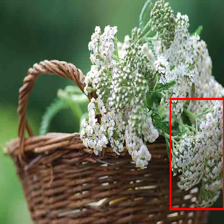

['A dense cluster of small, delicate white flowers with green stems and leaves, forming a rounded, bushy appearance.']

Our Results
['The visible part of the tree is adorned with dense, dark red foliage.', 'A dense cluster of small, delicate white flowers with green stems and leaves, forming a rounded, bushy appearance.', 'A dense, elongated flower bed featuring a variety of flowers and foliage. The bed includes clusters of small white flowers, interspersed with patches of green shrubs and larger, rounded bushes with a mix of green and reddish-brown leaves. The arrangement is lush and vibrant, with the flowers and shrubs creating a textured, layered appearance.', 'A dense cluster of vibrant pink flowers with elongated, tubular petals, each bloom emerging from a spike-like structure. The flowers are surrounded by lush green leaves with serrated edges.', 'A rectangular box with a blue border and a white interior, featuring a red horizontal stripe across the middle.', 'A white headband ad

In [92]:
# 展示top 5 的cands
# show_some_cand(cands[4])
# 如果是ours
query_idx = weak[121]
show_some_query_info(query_idx)

# print("our results")
ourcands = ourscand_names_json[query_idx] # len 50
show_candidates_results(ourcands, query_idx, "Our Results", max_display=10)


# print("baseline results")
baselinecands = baselinecand_names_json[query_idx]
show_candidates_results(baselinecands, query_idx, "Baseline Results", max_display=10)

In [70]:
# cand_pool[ourcands[1]]['box']